# Tutorial 05 -- Observables, States, and Visualization

Extract reduced qubit and cavity states, compute conditioned observables, and visualize a displaced cavity state in phase space.

**Prerequisites.** Tutorials 03 and 04 are useful prerequisites.


## 1. Goal

We will prepare a simple joint state, extract subsystem objects from the simulation result, and visualize both qubit and cavity observables.


## 2. Physical Background

`cqed_sim` separates trajectory generation from observable extraction. After a simulation you can reduce onto the qubit or storage subsystem, compute moments, and condition on a selected Fock level.


## 3. Imports


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from cqed_sim import (
    AmplifierChain,
    BosonicModeSpec,
    DispersiveCouplingSpec,
    DispersiveReadoutTransmonStorageModel,
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    NoiseSpec,
    Pulse,
    PurcellFilter,
    QubitMeasurementSpec,
    ReadoutChain,
    ReadoutResonator,
    RotationGate,
    SidebandDriveSpec,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    TransmonModeSpec,
    UniversalCQEDModel,
    build_displacement_pulse,
    build_rotation_pulse,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    coherent_state,
    compute_energy_spectrum,
    fock_state,
    manifold_transition_frequency,
    measure_qubit,
    prepare_simulation,
    prepare_state,
    pure_dephasing_time_from_t1_t2,
    qubit_state,
    run_rabi,
    run_ramsey,
    run_spectroscopy,
    run_t1,
    run_t2_echo,
    sideband_transition_frequency,
    simulate_batch,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from cqed_sim.pulses import gaussian_envelope, square_envelope
from cqed_sim.sim import (
    cavity_wigner,
    conditioned_bloch_xyz,
    mode_moments,
    qubit_conditioned_mode_moments,
    readout_response_by_qubit_state,
    reduced_cavity_state,
    reduced_qubit_state,
    reduced_storage_state,
    storage_photon_number,
    subsystem_level_population,
    transmon_level_populations,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    angular_to_ghz,
    angular_to_hz,
    angular_to_mhz,
    cross_kerr_conditional_phase,
    final_expectation,
    fit_echo_signal,
    fit_exponential_decay,
    fit_lorentzian_peak,
    fit_rabi_vs_amplitude,
    fit_rabi_vs_duration,
    fit_ramsey_signal,
    gaussian_quasistatic_echo_excited_population,
    gaussian_quasistatic_ramsey_excited_population,
    ns,
    ramsey_population,
    resonant_drive_excited_population,
    t1_relaxation_population,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 4. Simulation Parameters


In [2]:
rotation_duration = 40.0 * ns
displacement_duration = 120.0 * ns
dt = 2.0 * ns


## 5. Model Construction


In [3]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.05),
    omega_q=GHz(6.15),
    alpha=0.0,
    chi=0.0,
    kerr=0.0,
    n_cav=16,
    n_tr=2,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)
initial_state = model.basis_state(0, 0)


## 6. Pulse / Sequence Construction


In [4]:
disp_pulses, _, _ = build_displacement_pulse(
    DisplacementGate(index=0, name="D(alpha)", re=1.2, im=0.0),
    {"duration_displacement_s": displacement_duration},
)
rot_pulses, _, _ = build_rotation_pulse(
    RotationGate(index=1, name="x90", theta=np.pi / 2.0, phi=0.0),
    {"duration_rotation_s": rotation_duration, "rotation_sigma_fraction": 0.18},
)
qubit_pulse = rot_pulses[0]
shifted_qubit_pulse = Pulse(
    channel=qubit_pulse.channel,
    t0=displacement_duration + 10.0 * ns,
    duration=qubit_pulse.duration,
    envelope=qubit_pulse.envelope,
    amp=qubit_pulse.amp,
    carrier=qubit_pulse.carrier,
    phase=qubit_pulse.phase,
    label=qubit_pulse.label,
)
all_pulses = disp_pulses + [shifted_qubit_pulse]
drive_ops = {"storage": "cavity", "qubit": "qubit"}
compiled = SequenceCompiler(dt=dt).compile(all_pulses, t_end=displacement_duration + rotation_duration + 20.0 * ns)


## 7. Running the Simulation


In [5]:
result = simulate_sequence(
    model,
    compiled,
    initial_state,
    drive_ops,
    config=SimulationConfig(frame=frame),
)

rho_q = reduced_qubit_state(result.final_state)
rho_c = reduced_cavity_state(result.final_state)
moments = mode_moments(result.final_state, "storage")
conditioned_n0 = conditioned_bloch_xyz(result.final_state, n=0, fallback="zero")
conditioned_n1 = conditioned_bloch_xyz(result.final_state, n=1, fallback="zero")
print("Reduced qubit state:")
print(rho_q)
print(f"Storage <a> = {moments['a']:+.3f}")
print(f"Storage <n> = {moments['n']:.3f}")


Reduced qubit state:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[5.02088902e-01+0.j         3.21861650e-32+0.49999564j]
 [3.21861650e-32-0.49999564j 4.97911098e-01+0.j        ]]
Storage <a> = +1.190-0.000j
Storage <n> = 1.416


## 8. Visualizing the Results


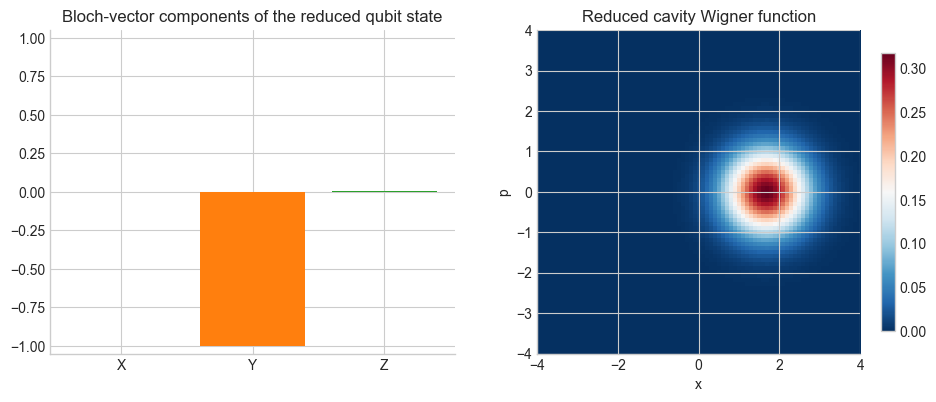

Conditioned Bloch vector for n = 0: (2.8729175968765785e-40, -0.999991272933937, 0.004177805161132031, 0.24266109830796773, True)
Conditioned Bloch vector for n = 1: (-2.690238589426482e-32, -0.9999912729349928, 0.00417780490840286, 0.3436298835869986, True)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
qubit_xyz = np.array([
    float(np.real((rho_q * qt.sigmax()).tr())),
    float(np.real((rho_q * qt.sigmay()).tr())),
    float(np.real((rho_q * qt.sigmaz()).tr())),
])
axes[0].bar(["X", "Y", "Z"], qubit_xyz, color=["tab:blue", "tab:orange", "tab:green"])
axes[0].set_ylim(-1.05, 1.05)
axes[0].set_title("Bloch-vector components of the reduced qubit state")

xvec, yvec, w = cavity_wigner(rho_c, n_points=81, extent=4.0)
image = axes[1].imshow(w, origin="lower", extent=[xvec[0], xvec[-1], yvec[0], yvec[-1]], cmap="RdBu_r", aspect="equal")
axes[1].set_xlabel("x")
axes[1].set_ylabel("p")
axes[1].set_title("Reduced cavity Wigner function")
fig.colorbar(image, ax=axes[1], shrink=0.86)
plt.show()

print("Conditioned Bloch vector for n = 0:", conditioned_n0)
print("Conditioned Bloch vector for n = 1:", conditioned_n1)


## 9. Physical Interpretation

The reduced qubit state captures the spin-like degrees of freedom, while the Wigner function keeps the cavity's phase-space picture. The conditioned Bloch vectors show how you can ask qubit questions inside a selected Fock sector.


## 10. Exercises / Next Steps

- Change the displacement amplitude and re-run the conditioned Bloch diagnostics.
- Add a nonzero `chi` and see how the qubit and cavity observables become correlated even for short sequences.
- Continue to Tutorial 07 for a direct use of Fock-conditioned spectroscopy.
